In [4]:
import mlflow

mlflow.set_tracking_uri(
    "sqlite:///C:/Users/RUSHI/mlflow.db"
)

mlflow.set_experiment("Sales_Amount_Prediction")

print("MLflow Tracking URI:")
print(mlflow.get_tracking_uri())

print("\nCurrent experiment:")
print(mlflow.get_experiment_by_name("Sales_Amount_Prediction"))

MLflow Tracking URI:
sqlite:///C:/Users/RUSHI/mlflow.db

Current experiment:
<Experiment: artifact_location='file:C:/Users/RUSHI/mlruns/3', creation_time=1788248661591, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1788248661591, lifecycle_stage='active', name='Sales_Amount_Prediction', tags={}, trace_location=None, workspace='default'>


In [6]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd()

print("Current Project:")
print(PROJECT_ROOT)

DATASET = PROJECT_ROOT / "sales_data.csv"

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

if DATASET.exists():
    print("\nSales dataset found!")
    print(DATASET)
else:
    print("\nERROR: sales_data.csv not found.")

Current Project:
C:\Users\RUSHI

Sales dataset found!
C:\Users\RUSHI\sales_data.csv


In [ ]:
!pip install ydata-profiling pandera mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.8/447.8 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import os
import shutil
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import shutil
df = pd.read_csv("sales_data.csv")
print("First Five Records:")
display(df.head())

# 2. Display number of rows and columns
print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# 3. Display all column names
print("\nColumn Names:")
print(df.columns.tolist())

# 4. Display data types
print("\nData Types:")
print(df.dtypes)

# 5. Create raw data directory
os.makedirs("data/raw", exist_ok=True)

# 6. Store original dataset without modification
shutil.copy("sales_data.csv", "data/raw/sales_data.csv")

print("\nOriginal dataset successfully stored in data/raw/")

First Five Records:


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie



Number of Rows: 1000
Number of Columns: 14

Column Names:
['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount', 'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price', 'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep']

Data Types:
Product_ID                int64
Sale_Date                object
Sales_Rep                object
Region                   object
Sales_Amount            float64
Quantity_Sold             int64
Product_Category         object
Unit_Cost               float64
Unit_Price              float64
Customer_Type            object
Discount                float64
Payment_Method           object
Sales_Channel            object
Region_and_Sales_Rep     object
dtype: object

Original dataset successfully stored in data/raw/


In [5]:
import shutil

raw_file = RAW_DIR / "sales_data.csv"

shutil.copy2(DATASET, raw_file)

print("Raw dataset copied to:")
print(raw_file)

Raw dataset copied to:
C:\Users\RUSHI\data\raw\sales_data.csv


In [ ]:
#2
!pip install ydata-profiling -q

In [ ]:
from ydata_profiling import ProfileReport
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#2.1 Generate profiling report
profile = ProfileReport(
    df,
    title="Sales Data Profiling Report",
    explorative=True
)

profile.to_file("sales_profiling_report.html")

print("Profiling report created successfully!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 43.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profiling report created successfully!


In [ ]:
#2.2 Numerical and categorical columns
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Product_ID', 'Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount']

Categorical Columns:
['Sale_Date', 'Sales_Rep', 'Region', 'Product_Category', 'Customer_Type', 'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep']


In [ ]:
#2.3,2.4 Missing values and duplicates
print("Missing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Records:")
print(df.duplicated().sum())

Missing Values:
Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

Number of Duplicate Records:
0


In [ ]:
#2.5 Unique values in categorical columns
for column in categorical_columns:
    print("\nColumn:", column)
    print("Number of Unique Values:", df[column].nunique())
    print("Unique Values:", df[column].unique())


Column: Sale_Date
Number of Unique Values: 340
Unique Values: ['2023-02-03' '2023-04-21' '2023-09-21' '2023-08-24' '2023-03-24'
 '2023-02-11' '2023-04-11' '2023-01-06' '2023-06-29' '2023-10-09'
 '2023-11-16' '2023-08-14' '2023-11-11' '2023-12-31' '2023-08-17'
 '2023-10-16' '2023-05-30' '2023-10-04' '2023-07-17' '2023-03-11'
 '2023-04-22' '2023-01-04' '2023-12-16' '2023-11-27' '2023-11-14'
 '2023-04-05' '2023-06-01' '2023-11-07' '2023-05-17' '2023-09-04'
 '2023-08-31' '2023-01-31' '2023-02-09' '2023-02-05' '2023-08-11'
 '2023-11-18' '2023-08-08' '2023-03-16' '2023-12-01' '2023-05-14'
 '2023-04-28' '2023-04-04' '2023-03-03' '2023-07-13' '2023-07-22'
 '2023-01-26' '2023-06-22' '2023-10-27' '2023-05-13' '2023-11-22'
 '2023-11-20' '2023-10-02' '2023-07-31' '2023-08-13' '2023-01-20'
 '2023-04-23' '2023-05-20' '2023-02-16' '2023-01-01' '2023-03-31'
 '2023-05-22' '2023-02-07' '2023-10-20' '2023-05-19' '2023-12-22'
 '2023-11-29' '2023-09-16' '2023-06-10' '2023-06-27' '2023-01-10'
 '2023-09-18'

In [ ]:
#2.6 Numerical statistics
df[numerical_columns].describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


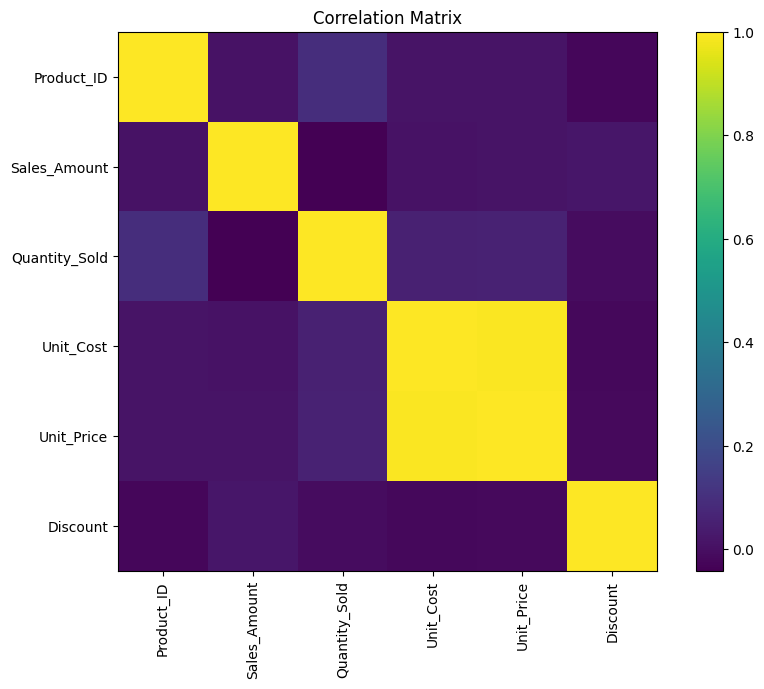

In [ ]:
#2.8 Correlation matrix
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix)
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
#2
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(column, ":", len(outliers), "outliers")

Product_ID : 0 outliers
Sales_Amount : 0 outliers
Quantity_Sold : 0 outliers
Unit_Cost : 0 outliers
Unit_Price : 0 outliers
Discount : 0 outliers


In [ ]:
#3 Install Pandera
!pip install pandera -q

In [ ]:
#3 import
import pandera.pandas as pa
from pandera import Column, Check

In [ ]:
#3 Create Validation Schema
sales_schema = pa.DataFrameSchema(
    {
        "Product_ID": Column(
            int,
            nullable=False,
            coerce=True
        ),

        "Sale_Date": Column(
            object,
            nullable=False
        ),

        "Sales_Rep": Column(
            str,
            nullable=False
        ),

        "Region": Column(
            str,
            nullable=False
        ),

        "Sales_Amount": Column(
            float,
            Check.greater_than_or_equal_to(0),
            nullable=False,
            coerce=True
        ),

        "Quantity_Sold": Column(
            int,
            Check.greater_than_or_equal_to(0),
            nullable=False,
            coerce=True
        ),

        "Product_Category": Column(
            str,
            nullable=False
        ),

        "Unit_Cost": Column(
            float,
            Check.greater_than_or_equal_to(0),
            nullable=False,
            coerce=True
        ),

        "Unit_Price": Column(
            float,
            Check.greater_than_or_equal_to(0),
            nullable=False,
            coerce=True
        ),

        "Customer_Type": Column(
            str,
            nullable=False
        ),

        "Discount": Column(
            float,
            Check.in_range(0, 1),
            nullable=False,
            coerce=True
        ),

        "Payment_Method": Column(
            str,
            nullable=False
        ),

        "Sales_Channel": Column(
            str,
            nullable=False
        ),

        "Region_and_Sales_Rep": Column(
            str,
            nullable=False
        )
    },

    strict=False
)

In [ ]:
#3Validate the dataset
try:

    validated_df = sales_schema.validate(
        df,
        lazy=True
    )

    print("Dataset validation successful!")

except pa.errors.SchemaErrors as e:

    print("Validation errors found!")

    display(e.failure_cases)

Dataset validation successful!


In [ ]:
#4
import pandas as pd
import numpy as np
import os

sales_processed = df.copy()

# 1. Remove duplicate records
sales_processed = sales_processed.drop_duplicates()

# 2. Convert Sale_Date to datetime
sales_processed["Sale_Date"] = pd.to_datetime(
    sales_processed["Sale_Date"],
    errors="coerce"
)

# 3. Handle missing values in numerical columns
numerical_columns = sales_processed.select_dtypes(
    include=np.number
).columns

for column in numerical_columns:

    sales_processed[column] = sales_processed[column].fillna(
        sales_processed[column].median()
    )

# 4. Handle missing values in categorical columns
categorical_columns = sales_processed.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:

    sales_processed[column] = sales_processed[column].fillna(
        sales_processed[column].mode()[0]
    )

# 5. Standardize categorical values
for column in categorical_columns:

    sales_processed[column] = (
        sales_processed[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# 6. Handle invalid negative values
positive_columns = [
    "Sales_Amount",
    "Quantity_Sold",
    "Unit_Cost",
    "Unit_Price"
]

for column in positive_columns:

    sales_processed.loc[
        sales_processed[column] < 0,
        column
    ] = np.nan

    sales_processed[column] = sales_processed[column].fillna(
        sales_processed[column].median()
    )

# 7. Handle invalid Discount values
sales_processed.loc[
    (sales_processed["Discount"] < 0) |
    (sales_processed["Discount"] > 1),
    "Discount"
] = sales_processed["Discount"].median()

# Create processed directory
os.makedirs("data/processed", exist_ok=True)

# Save processed dataset
sales_processed.to_csv(
    "data/processed/sales_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

display(sales_processed.head())

Processed dataset saved successfully!


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,bob,north,5053.97,18.0,furniture,152.75,267.22,returning,0.09,cash,online,north-bob
1,1093,2023-04-21,bob,west,4384.02,17.0,furniture,3816.39,4209.44,returning,0.11,cash,retail,west-bob
2,1015,2023-09-21,david,south,4631.23,30.0,food,261.56,371.40,returning,0.20,bank transfer,retail,south-david
3,1072,2023-08-24,bob,south,2167.94,39.0,clothing,4330.03,4467.75,new,0.02,credit card,retail,south-bob
4,1061,2023-03-24,charlie,east,3750.20,13.0,electronics,637.37,692.71,new,0.08,credit card,online,east-charlie


In [ ]:
#5 Data Pipeline
import os
import pandas as pd
import numpy as np

In [ ]:
#5 Create Pipeline functions
def ingest_data(file_path):

    data = pd.read_csv(file_path)

    print("Data ingestion completed!")

    return data

def save_processed_data(data):
    os.makedirs("data/processed", exist_ok=True)
    data.to_csv("data/processed/sales_processed.csv", index=False)
    print("Processed data saved to data/processed/sales_processed.csv")

In [ ]:
#5
def profile_data(data):

    print("Dataset Shape:", data.shape)

    print("\nMissing Values:")
    print(data.isnull().sum())

    print("\nDuplicate Records:")
    print(data.duplicated().sum())

    return data

In [ ]:
#5
def validate_data(data):

    try:

        sales_schema.validate(
            data,
            lazy=True
        )

        print("Data validation successful!")

    except pa.errors.SchemaErrors as e:

        print("Validation errors found!")

        display(e.failure_cases)

    return data

In [ ]:
#5
def clean_data(data):

    data = data.copy()

    # Remove duplicates
    data = data.drop_duplicates()

    # Convert date
    data["Sale_Date"] = pd.to_datetime(
        data["Sale_Date"],
        errors="coerce"
    )

    # Numerical missing values
    numerical_columns = data.select_dtypes(
        include=np.number
    ).columns

    for column in numerical_columns:

        data[column] = data[column].fillna(
            data[column].median()
        )

    # Categorical missing values
    categorical_columns = data.select_dtypes(
        include=["object"]
    ).columns

    for column in categorical_columns:

        data[column] = data[column].fillna(
            data[column].mode()[0]
        )

        data[column] = (
            data[column]
            .astype(str)
            .str.strip()
            .str.lower()
        )

    # Invalid values
    positive_columns = [
        "Sales_Amount",
        "Quantity_Sold",
        "Unit_Cost",
        "Unit_Price"
    ]

    for column in positive_columns:

        data.loc[
            data[column] < 0,
            column
        ] = data[column].median()

    data.loc[
        (data["Discount"] < 0) |
        (data["Discount"] > 1),
        "Discount"
    ] = data["Discount"].median()

    return data

In [ ]:
#5
def transform_data(data):

    data = data.copy()

    # Ensure correct date format
    data["Sale_Date"] = pd.to_datetime(
        data["Sale_Date"],
        errors="coerce"
    )

    return data

In [ ]:
#5 Main pipeline
def run_pipeline(file_path):

    print("STEP 1: Data Ingestion")
    data = ingest_data(file_path)

    print("\nSTEP 2: Data Profiling")
    profile_data(data)

    print("\nSTEP 3: Data Validation")
    validate_data(data)

    print("\nSTEP 4: Data Cleaning")
    data = clean_data(data)

    print("\nSTEP 5: Data Transformation")
    data = transform_data(data)

    print("\nSTEP 6: Save Processed Data")
    save_processed_data(data)

    print("\nPipeline executed successfully!")

    return data

In [ ]:
#6 Feature Engineering
sales_features = sales_processed.copy()

# Gross Sales Value
sales_features["Gross_Sales_Value"] = (
    sales_features["Quantity_Sold"] *
    sales_features["Unit_Price"]
)

# Total Cost
sales_features["Total_Cost"] = (
    sales_features["Quantity_Sold"] *
    sales_features["Unit_Cost"]
)

# Estimated Margin
sales_features["Estimated_Margin"] = (
    sales_features["Unit_Price"] -
    sales_features["Unit_Cost"]
)

# Discount Amount
sales_features["Discount_Amount"] = (
    sales_features["Gross_Sales_Value"] *
    sales_features["Discount"]
)

# Date features
sales_features["Sale_Date"] = pd.to_datetime(
    sales_features["Sale_Date"]
)

sales_features["Sale_Year"] = (
    sales_features["Sale_Date"].dt.year
)

sales_features["Sale_Month"] = (
    sales_features["Sale_Date"].dt.month
)

sales_features["Sale_Day"] = (
    sales_features["Sale_Date"].dt.day
)

sales_features["Day_Of_Week"] = (
    sales_features["Sale_Date"].dt.dayofweek
)

# Save feature engineered data
sales_features.to_csv(
    "data/processed/sales_features.csv",
    index=False
)

display(sales_features.head())

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,...,Sales_Channel,Region_and_Sales_Rep,Gross_Sales_Value,Total_Cost,Estimated_Margin,Discount_Amount,Sale_Year,Sale_Month,Sale_Day,Day_Of_Week
0,1052,2023-02-03,bob,north,5053.97,18.0,furniture,152.75,267.22,returning,...,online,north-bob,4809.96,2749.50,114.47,432.8964,2023,2,3,4
1,1093,2023-04-21,bob,west,4384.02,17.0,furniture,3816.39,4209.44,returning,...,retail,west-bob,71560.48,64878.63,393.05,7871.6528,2023,4,21,4
2,1015,2023-09-21,david,south,4631.23,30.0,food,261.56,371.40,returning,...,retail,south-david,11142.00,7846.80,109.84,2228.4000,2023,9,21,3
3,1072,2023-08-24,bob,south,2167.94,39.0,clothing,4330.03,4467.75,new,...,retail,south-bob,174242.25,168871.17,137.72,3484.8450,2023,8,24,3
4,1061,2023-03-24,charlie,east,3750.20,13.0,electronics,637.37,692.71,new,...,online,east-charlie,9005.23,8285.81,55.34,720.4184,2023,3,24,4


In [ ]:
#7 Create raw data folder and copy dataset
import os
import shutil


os.makedirs("data/raw", exist_ok=True)


shutil.copy(
    "sales_data.csv",
    "data/raw/sales_data.csv"
)

'data/raw/sales_data.csv'

In [ ]:
#8 Prepare ML-Ready Data
from sklearn.model_selection import train_test_split

In [ ]:
#8
ml_data = sales_features.copy()

# Remove original date column because datetime cannot be directly used
ml_data = ml_data.drop(
    columns=["Sale_Date"]
)

# Separate features and target
X = ml_data.drop(
    columns=["Sales_Amount"]
)

y = ml_data["Sales_Amount"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1000, 20)
Target Shape: (1000,)


In [ ]:
#8 Train-test split
X_train, X_test, y_train, y_test = train_test_split(


    X,
    y,


    test_size=0.20,


    random_state=42
)


print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)


print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (800, 20)
Testing Features: (200, 20)
Training Target: (800,)
Testing Target: (200,)


In [ ]:
#9 Data Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
# 9 Identify feature types
numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()


categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


print("Numerical Features:")
print(numerical_features)


print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Product_ID', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount', 'Gross_Sales_Value', 'Total_Cost', 'Estimated_Margin', 'Discount_Amount', 'Sale_Year', 'Sale_Month', 'Sale_Day', 'Day_Of_Week']

Categorical Features:
['Sales_Rep', 'Region', 'Product_Category', 'Customer_Type', 'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep']


In [ ]:
# 9 Numerical preprocessing
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),


        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [ ]:
# 9 Categorical preprocessing
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),


        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [ ]:
# 9 Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),


        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
#10 Model Training and Evaluation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
#10 Create model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [ ]:
# 10 Create complete ML pipeline
model_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),


        (
            "model",
            model
        )
    ]
)

In [ ]:
#10 Train model
model_pipeline.fit(
    X_train,
    y_train
)


print("Model training completed!")

Model training completed!


In [ ]:
#10 Predictions
y_pred = model_pipeline.predict(
    X_test
)

In [ ]:
#10 Evaluation
mae = mean_absolute_error(
    y_test,
    y_pred
)


rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


r2 = r2_score(
    y_test,
    y_pred
)


print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 2775.0726990000003
RMSE: 3164.069363001096
R² Score: -0.08332289396085568


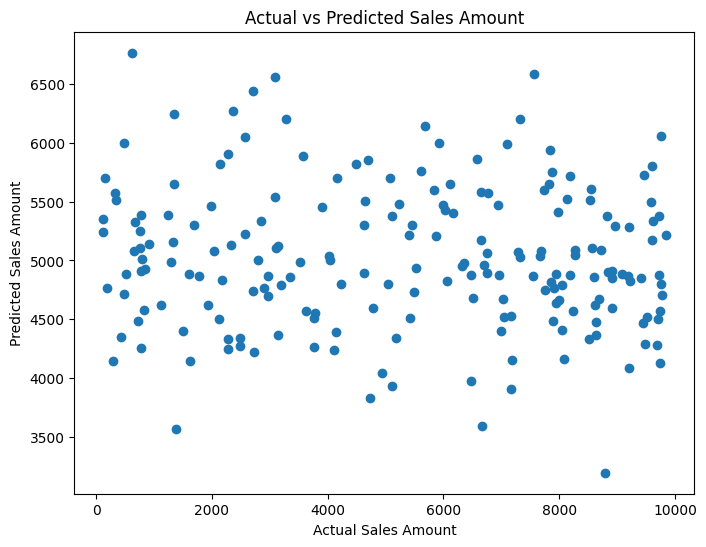

In [ ]:
#10 Actual vs Predicted graph
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))


plt.scatter(
    y_test,
    y_pred
)


plt.xlabel("Actual Sales Amount")
plt.ylabel("Predicted Sales Amount")


plt.title("Actual vs Predicted Sales Amount")


plt.show()

In [ ]:
# 11 MLflow Experiment Tracking
#Install MLflow
!pip install mlflow -q

In [ ]:
#11Import MLflow
import mlflow
import mlflow.sklearn

In [ ]:
#11 Set experiment
mlflow.set_experiment(
    "Sales_Amount_Prediction"
)

2026/08/14 06:32:37 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/14 06:32:37 INFO mlflow.store.db.utils: Updating database tables
2026/08/14 06:32:41 INFO mlflow.tracking.fluent: Experiment with name 'Sales_Amount_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1786689161695, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1786689161695, lifecycle_stage='active', name='Sales_Amount_Prediction', tags={}, trace_location=None, workspace='default'>

In [ ]:
#11 Run MLflow experiment
import mlflow
import mlflow.sklearn

mlflow.set_experiment("Sales_Amount_Prediction")

with mlflow.start_run():

    # Train model
    model_pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = model_pipeline.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    # Log parameters
    mlflow.log_param(
        "model_name",
        "RandomForestRegressor"
    )

    mlflow.log_param(
        "n_estimators",
        200
    )

    mlflow.log_param(
        "random_state",
        42
    )

    # Log metrics
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2_Score", r2)

    # Log model using cloudpickle
    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="sales_prediction_model",
        serialization_format="cloudpickle"
    )

    print("MLflow experiment completed successfully!")

    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R² Score:", r2)

2026/08/14 06:37:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow experiment completed successfully!
MAE: 2775.0726990000003
RMSE: 3164.069363001096
R² Score: -0.08332289396085568


In [ ]:
#12 Complete ML workflow
def complete_mlops_pipeline(file_path):

    import os
    import pandas as pd
    import numpy as np
    import mlflow
    import mlflow.sklearn

    from sklearn.model_selection import train_test_split
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import (
        mean_absolute_error,
        mean_squared_error,
        r2_score
    )

    print("=" * 60)
    print("STEP 1: DATA INGESTION")
    print("=" * 60)

    data = pd.read_csv(file_path)

    print("Data ingestion completed!")
    print("Dataset Shape:", data.shape)


    # =========================================================
    # STEP 2: DATA PROFILING
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 2: DATA PROFILING")
    print("=" * 60)

    print("Dataset Shape:", data.shape)

    print("\nMissing Values:")
    print(data.isnull().sum())

    print("\nDuplicate Records:")
    print(data.duplicated().sum())


    # =========================================================
    # STEP 3: DATA VALIDATION
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 3: DATA VALIDATION")
    print("=" * 60)

    validation_errors = []

    # Quantity_Sold validation
    if (data["Quantity_Sold"] < 0).any():
        validation_errors.append(
            "Quantity_Sold contains negative values"
        )

    # Unit_Cost validation
    if (data["Unit_Cost"] < 0).any():
        validation_errors.append(
            "Unit_Cost contains negative values"
        )

    # Unit_Price validation
    if (data["Unit_Price"] < 0).any():
        validation_errors.append(
            "Unit_Price contains negative values"
        )

    # Sales_Amount validation
    if (data["Sales_Amount"] < 0).any():
        validation_errors.append(
            "Sales_Amount contains negative values"
        )

    # Discount validation
    if (
        (data["Discount"] < 0).any()
        or
        (data["Discount"] > 1).any()
    ):
        validation_errors.append(
            "Discount contains invalid values"
        )

    if len(validation_errors) == 0:
        print("Data validation successful!")
    else:
        print("Validation errors:")
        for error in validation_errors:
            print("-", error)


    # =========================================================
    # STEP 4: DATA CLEANING AND ENGINEERING
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 4: DATA ENGINEERING")
    print("=" * 60)

    processed_data = data.copy()

    # Remove duplicates
    processed_data = processed_data.drop_duplicates()

    # Convert date
    processed_data["Sale_Date"] = pd.to_datetime(
        processed_data["Sale_Date"],
        errors="coerce"
    )

    # Numerical columns
    numerical_columns = processed_data.select_dtypes(
        include=np.number
    ).columns.tolist()

    # Fill missing numerical values
    for column in numerical_columns:
        processed_data[column] = processed_data[column].fillna(
            processed_data[column].median()
        )

    # Categorical columns
    categorical_columns = processed_data.select_dtypes(
        include=["object"]
    ).columns.tolist()

    # Fill missing categorical values
    for column in categorical_columns:

        if processed_data[column].isnull().any():

            processed_data[column] = processed_data[column].fillna(
                processed_data[column].mode()[0]
            )

        # Standardize text
        processed_data[column] = (
            processed_data[column]
            .astype(str)
            .str.strip()
            .str.lower()
        )

    # Handle invalid negative values
    positive_columns = [
        "Sales_Amount",
        "Quantity_Sold",
        "Unit_Cost",
        "Unit_Price"
    ]

    for column in positive_columns:

        processed_data.loc[
            processed_data[column] < 0,
            column
        ] = processed_data[column].median()

    # Handle invalid discount
    processed_data.loc[
        (
            processed_data["Discount"] < 0
        )
        |
        (
            processed_data["Discount"] > 1
        ),
        "Discount"
    ] = processed_data["Discount"].median()

    print("Data cleaning completed!")
    print("Processed Data Shape:", processed_data.shape)


    # =========================================================
    # STEP 5: SAVE PROCESSED DATA
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 5: SAVE PROCESSED DATA")
    print("=" * 60)

    os.makedirs(
        "data/processed",
        exist_ok=True
    )

    processed_data.to_csv(
        "data/processed/sales_processed.csv",
        index=False
    )

    print("Processed data saved successfully!")


    # =========================================================
    # STEP 6: FEATURE ENGINEERING
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 6: FEATURE ENGINEERING")
    print("=" * 60)

    feature_data = processed_data.copy()

    # Gross Sales Value
    feature_data["Gross_Sales_Value"] = (
        feature_data["Quantity_Sold"]
        *
        feature_data["Unit_Price"]
    )

    # Total Cost
    feature_data["Total_Cost"] = (
        feature_data["Quantity_Sold"]
        *
        feature_data["Unit_Cost"]
    )

    # Estimated Margin
    feature_data["Estimated_Margin"] = (
        feature_data["Unit_Price"]
        -
        feature_data["Unit_Cost"]
    )

    # Discount Amount
    feature_data["Discount_Amount"] = (
        feature_data["Gross_Sales_Value"]
        *
        feature_data["Discount"]
    )

    # Date features
    feature_data["Sale_Year"] = (
        feature_data["Sale_Date"].dt.year
    )

    feature_data["Sale_Month"] = (
        feature_data["Sale_Date"].dt.month
    )

    feature_data["Sale_Day"] = (
        feature_data["Sale_Date"].dt.day
    )

    feature_data["Day_Of_Week"] = (
        feature_data["Sale_Date"].dt.dayofweek
    )

    print("Feature engineering completed!")

    print("New Dataset Shape:", feature_data.shape)


    # =========================================================
    # STEP 7: PREPARE ML DATA
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 7: PREPARE ML DATA")
    print("=" * 60)

    # Remove date column
    ml_data = feature_data.drop(
        columns=["Sale_Date"]
    )

    # Separate X and y
    X = ml_data.drop(
        columns=["Sales_Amount"]
    )

    y = ml_data["Sales_Amount"]

    # Train test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

    print("Training Data Shape:", X_train.shape)

    print("Testing Data Shape:", X_test.shape)


    # =========================================================
    # STEP 8: PREPROCESSING PIPELINE
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 8: DATA PREPROCESSING")
    print("=" * 60)

    numerical_features = X.select_dtypes(
        include=np.number
    ).columns.tolist()

    categorical_features = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    # Numerical preprocessing
    numerical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    # Categorical preprocessing
    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )

    # Combine preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numerical",
                numerical_pipeline,
                numerical_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    print("Preprocessing pipeline created!")


    # =========================================================
    # STEP 9: MODEL TRAINING
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 9: MODEL TRAINING")
    print("=" * 60)

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    model_pipeline.fit(
        X_train,
        y_train
    )

    print("Model training completed!")


    # =========================================================
    # STEP 10: MODEL EVALUATION
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 10: MODEL EVALUATION")
    print("=" * 60)

    predictions = model_pipeline.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R² Score:", round(r2, 4))


    # =========================================================
    # STEP 11: MLFLOW EXPERIMENT TRACKING
    # =========================================================

    print("\n" + "=" * 60)
    print("STEP 11: MLFLOW EXPERIMENT TRACKING")
    print("=" * 60)

    mlflow.set_experiment(
        "Sales_Amount_Prediction"
    )

    with mlflow.start_run():

        # Log parameters
        mlflow.log_param(
            "model_name",
            "RandomForestRegressor"
        )

        mlflow.log_param(
            "n_estimators",
            200
        )

        mlflow.log_param(
            "random_state",
            42
        )

        # Log metrics
        mlflow.log_metric(
            "MAE",
            mae
        )

        mlflow.log_metric(
            "RMSE",
            rmse
        )

        mlflow.log_metric(
            "R2_Score",
            r2
        )

        # Log trained model
        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            name="sales_prediction_model",
            serialization_format="cloudpickle"
        )

    print("MLflow experiment completed successfully!")


    # =========================================================
    # PIPELINE COMPLETED
    # =========================================================

    print("\n" + "=" * 60)
    print("COMPLETE MLOPS PIPELINE EXECUTED SUCCESSFULLY!")
    print("=" * 60)

    return model_pipeline, mae, rmse, r2

In [ ]:
final_model, final_mae, final_rmse, final_r2 = complete_mlops_pipeline(
    "sales_data.csv"
)

STEP 1: DATA INGESTION
Data ingestion completed!
Dataset Shape: (1000, 14)

STEP 2: DATA PROFILING
Dataset Shape: (1000, 14)

Missing Values:
Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

Duplicate Records:
0

STEP 3: DATA VALIDATION
Data validation successful!

STEP 4: DATA ENGINEERING
Data cleaning completed!
Processed Data Shape: (1000, 14)

STEP 5: SAVE PROCESSED DATA
Processed data saved successfully!

STEP 6: FEATURE ENGINEERING
Feature engineering completed!
New Dataset Shape: (1000, 22)

STEP 7: PREPARE ML DATA
Training Data Shape: (800, 20)
Testing Data Shape: (200, 20)

STEP 8: DATA PREPROCESSING
Preprocessing pipeline created!

STEP 9: MODEL TRAININ

2026/08/14 06:43:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow experiment completed successfully!

COMPLETE MLOPS PIPELINE EXECUTED SUCCESSFULLY!


In [ ]:
#12 Final Result
print("FINAL RESULTS")
print("=" * 30)
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R² Score:", final_r2)

FINAL RESULTS
MAE: 2775.0726990000003
RMSE: 3164.069363001096
R² Score: -0.08332289396085568


In [8]:
# Change to project directory
import os
%cd C:\Users\RUSHI\Sales_Amount_Prediction_mlops

print("Project directory:")
print(os.getcwd())

C:\Users\RUSHI\Sales_Amount_Prediction_mlops
Project directory:
C:\Users\RUSHI\Sales_Amount_Prediction_mlops


In [9]:
# Check project files

!dir

 Volume in drive C is Windows
 Volume Serial Number is B224-CD66

 Directory of C:\Users\RUSHI\sales_amount_prediction_mlops

01-09-2026  13:27    <DIR>          .
01-09-2026  13:28    <DIR>          ..
29-08-2026  09:23           105,083 sales_data.csv
01-09-2026  13:25           265,455 Sales_Prediction_MLOps.ipynb
               2 File(s)        370,538 bytes
               2 Dir(s)  355,296,710,656 bytes free


In [12]:
!git init

Initialized empty Git repository in C:/Users/RUSHI/sales_amount_prediction_mlops/.git/


In [13]:
# Question — Create .gitignore

gitignore_content = """__pycache__/
*.pyc
*.pyo

.ipynb_checkpoints/

.env
.venv/
venv/

mlruns/
mlflow.db

*.log
.DS_Store

*.pkl
*.joblib

.dvc/cache/
"""

with open(".gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore_content)

print(".gitignore created successfully.")

.gitignore created successfully.


In [14]:
# Check what will be committed

!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.gitignore
	Sales_Prediction_MLOps.ipynb
	sales_data.csv

nothing added to commit but untracked files present (use "git add" to track)


In [15]:
# Stage project files

!git add .

In [16]:
# Verify staged files

!git status

On branch master

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .gitignore
	new file:   Sales_Prediction_MLOps.ipynb
	new file:   sales_data.csv



In [17]:
# Configure Git username and email

!git config --global user.name "RushiKeshavPeddi"
!git config --global user.email "rushikeshav673@gmail.com"

In [ ]:
import os

target = "231FA04259-EXP3.ipynb"

print("Searching...")

for root, dirs, files in os.walk(r"C:\Users\RUSHI"):
    if target in files:
        print("FOUND:")
        print(os.path.join(root, target))

Searching...
FOUND:
C:\Users\RUSHI\231FA04259-EXP3.ipynb


In [4]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
